# Relation Extraction Evaluation

This notebook compares **ground-truth (GT) relations**, manually annotated in
`hagio_full_task_<id>_norm.json` files, against relations **found by a
model / rule-based matching pipeline**.

It produces four evaluation artifacts, all saved to
`evaluation/<gt_dir_name>_eval/`:

1. **Overall metrics table** — GT count, TP, FP, FN, accuracy, precision, recall, F1 (per relation label).
2. **Confusion matrix** — relation label (incl. `no_relation`) vs. predicted label.
3. **Subtype metrics table** — same metrics, broken down by *subtype*, where a subtype
   is a specific `head_entity_type -> tail_entity_type` pair for a given relation
   (e.g. `object->place`, `institution->place`).
4. **Subtype confusion matrix** — true subtype vs. predicted subtype.

### Supported prediction formats

`PRED_FILE` (see Configuration below) can point to **either**:

- **A single flat JSON file** — a list of relation dicts, each carrying the raw
  mention text (`head`, `tail`), entity types, a `context` sentence, and a
  `source_file` linking it to a GT document
  (e.g. `hagio_full2_spacy_rels-is_located_at_norm_rel_full.json`).
  These relations don't carry entity IDs, so they're resolved to GT entities by
  locating the mention text inside the `context` sentence, and the `context`
  inside the GT document text.

- **A folder of per-document JSON files**, each shaped like an NER/RE
  annotation export: `{"text": ..., "entities": [{"start","end","label","text","id"}, ...],
  "relations": [{"from_id","to_id","label","direction"}, ...], "task_id": ...}`
  (e.g. `hagio_NER_task_12008.json`, `hagio_NER_task_12009.json`).
  Here each relation already references specific entity spans, so those spans
  are matched directly against the GT document. The GT document itself is
  looked up by comparing **document text**, not `task_id` — prediction files
  and GT files commonly use unrelated id schemes for the same underlying
  document, so ids can't be trusted to line up. No context search needed
  once the right GT document is found.

Both formats are auto-detected and normalized into the same internal
representation before evaluation, so every downstream step (matching, metrics,
confusion matrices) behaves identically regardless of which format you feed in.

### How matching works

Ground-truth relations link two **entity IDs** (`head`, `child`). Predicted
relations are **resolved** to GT entity IDs as follows:

- **Flat/context format:** locate the `context` sentence inside the full
  document text, locate the `head`/`tail` mention text inside that context,
  and map the resulting character span onto the GT entity whose span contains it.
- **Entity/span format:** first identify which GT document a prediction
  file belongs to by matching its `text` field against each GT document's
  text (not `task_id`, since the two may use different id schemes), then map
  the predicted entity's own `start`/`end` span directly onto the GT entity
  whose span contains it.

Once every predicted relation is expressed as an `(head_id, tail_id)` pair, it
can be compared directly against the GT `(head, child)` pairs.

> **A note on "accuracy":** true negatives are not well defined for relation
> extraction over free text (the space of unrelated entity pairs is huge and not
> meaningful). We therefore report accuracy as
> `TP / (TP + FP + FN)` — the fraction of *all relation instances considered*
> (gold ∪ predicted) that were identified correctly. This is standard practice
> for RE evaluation and is equivalent to the Jaccard index over the two relation
> sets.

# evaluation workflow

## count your GT entities and relations
To get a sense of the size of the evaluation task, count the number of entities and relations in the GT files. Through doing this, you know how many examples you have in your ground truth data, and you can compare it to the number of predictions your model or pipeline produces. This will help you understand the coverage of your predictions and whether your model is over-predicting or under-predicting relations.

In [2]:
import json
from collections import Counter

with open('sample_texts/relation-annotated-example.json') as f:
    data = json.load(f)

n_tasks = len(data)

entity_counter = Counter()
relation_counter = Counter()
n_annotations = 0

for task in data:
    for annotation in task.get('annotations', []):
        n_annotations += 1
        for result in annotation.get('result', []):
            if result['type'] == 'labels':
                for label in result['value']['labels']:
                    entity_counter[label] += 1
            elif result['type'] == 'relation':
                for label in result.get('labels', []):
                    relation_counter[label] += 1

print(f"Tasks: {n_tasks}")
print(f"Annotations: {n_annotations}")

print("\nEntity types:")
for label, count in entity_counter.most_common():
    print(f"  {label:20s} {count}")
print(f"  {'TOTAL':20s} {sum(entity_counter.values())}")

print("\nRelation types:")
for label, count in relation_counter.most_common():
    print(f"  {label:20s} {count}")
print(f"  {'TOTAL':20s} {sum(relation_counter.values())}")

Tasks: 39
Annotations: 39

Entity types:
  person               249
  place                140
  divine_entity        90
  institution          78
  object               68
  group                65
  pronoun              11
  text_title           1
  TOTAL                702

Relation types:
  is_owned_by          12
  goes_to              11
  is_located_at        10
  resides_at           8
  is_related_to        7
  acts_on              6
  is_called            4
  owns                 3
  founds               2
  comes_from           2
  TOTAL                65


## Configuration

Adjust these paths for the batch you want to evaluate.

In [30]:

from pathlib import Path

# --- Repo layout -----------------------------------------------------------
REPO_ROOT = Path.cwd()          # assumes the notebook lives at the repo root
                                 # change to Path("/path/to/repo") if needed

# Directory containing the ground-truth `hagio_full_task_<id>_norm.json` files
# for THIS batch:
GT_DIR = REPO_ROOT / "sample_texts" / "hagio_REX_annotation_53_spacy"

# Predictions for this batch. This can be EITHER:
#   - a single JSON file containing a flat list of relation dicts
#     (head/tail mention text + context), or
#   - a directory containing one JSON file per document, each with its own
#     "entities" (with spans) and "relations" (from_id/to_id) -- e.g. an
#     NER/RE annotation export.
# The format is auto-detected in section 2 below; you don't need to tell the
# notebook which kind it is.
PRED_FILE = REPO_ROOT / "pre-annotations" / "hagio_preannotation_GPT_53"

# Output directory: evaluation/<gt_dir_name>_eval/
OUTPUT_DIR = REPO_ROOT / "evaluation" / f"{PRED_FILE.name}_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Some matching pipelines emit several rule-specific relation labels for the
# same semantic relation (e.g. "is_located_at_verb", "is_located_at_direct").
# Normalize them to a single canonical relation label here.
REL_NORMALIZATION = {
    "is_located_at_verb": "is_located_at",
    "is_located_at_direct": "is_located_at",
    "is_located_at_relclause": "is_located_at",
}

# If True, a predicted (head, tail) pair will also be checked against the
# GT pair with head/tail swapped. Leave False unless your pipeline's head/tail
# convention might not match the GT head/child convention.
MATCH_DIRECTION_AGNOSTIC = False

print("GT_DIR    :", GT_DIR)
print("PRED_FILE :", PRED_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)


GT_DIR    : C:\Users\Heike\PycharmProjects\Hagiographics-relation-extraction\sample_texts\hagio_REX_annotation_53_spacy
PRED_FILE : C:\Users\Heike\PycharmProjects\Hagiographics-relation-extraction\pre-annotations\hagio_preannotation_GPT_53
OUTPUT_DIR: C:\Users\Heike\PycharmProjects\Hagiographics-relation-extraction\evaluation\hagio_preannotation_GPT_53_eval


In [31]:

import json, re, glob, os
from difflib import SequenceMatcher

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

pd.set_option("display.max_colwidth", 60)

def normalize_relation(label):
    return REL_NORMALIZATION.get(label, label)

def norm_ws(s):
    return re.sub(r"\s+", " ", s).strip()


## 1. Load ground-truth relations

In [32]:

def load_ground_truth(gt_dir):
    '''Load every hagio_full_task_*_norm.json file in gt_dir.

    Returns {filename: {"text": str, "entities": {id: entity_dict},
                          "relations": [...], "task_id": int}}
    '''
    docs = {}
    for path in sorted(glob.glob(os.path.join(gt_dir, "*.json"))):
        fname = os.path.basename(path)
        with open(path, encoding="utf-8") as f:
            data = json.load(f)
        ent_by_id = {e["id"]: e for e in data["entities"]}
        docs[fname] = {
            "text": data["text"],
            "entities": ent_by_id,
            "relations": data.get("relations", []),
            "task_id": data.get("task_id"),
        }
    return docs

gt_docs = load_ground_truth(GT_DIR)

n_gt_relations = sum(len(d["relations"]) for d in gt_docs.values())
print(f"Loaded {len(gt_docs)} ground-truth files, {n_gt_relations} GT relations total.")
for fname, d in gt_docs.items():
    print(f"  {fname}: {len(d['entities'])} entities, {len(d['relations'])} relations")


Loaded 53 ground-truth files, 263 GT relations total.
  hagio_REX_annotation_53_task_21194.json: 32 entities, 6 relations
  hagio_REX_annotation_53_task_21195.json: 11 entities, 4 relations
  hagio_REX_annotation_53_task_21196.json: 20 entities, 3 relations
  hagio_REX_annotation_53_task_21197.json: 15 entities, 4 relations
  hagio_REX_annotation_53_task_21198.json: 8 entities, 0 relations
  hagio_REX_annotation_53_task_21199.json: 15 entities, 4 relations
  hagio_REX_annotation_53_task_21200.json: 19 entities, 2 relations
  hagio_REX_annotation_53_task_21201.json: 17 entities, 7 relations
  hagio_REX_annotation_53_task_21202.json: 7 entities, 1 relations
  hagio_REX_annotation_53_task_21203.json: 36 entities, 12 relations
  hagio_REX_annotation_53_task_21204.json: 26 entities, 15 relations
  hagio_REX_annotation_53_task_21205.json: 12 entities, 2 relations
  hagio_REX_annotation_53_task_21206.json: 16 entities, 4 relations
  hagio_REX_annotation_53_task_21207.json: 17 entities, 1 rela

## 2. Load predicted relations

`PRED_FILE` can be a single flat-list JSON file, or a directory of
per-document JSON files. Each file's format is auto-detected:

- a JSON **list** &rarr; treated as flat relation dicts (`head`/`tail` mention
  text + `context`), matched to a GT document via their own `source_file` field.
- a JSON **dict** containing `"entities"` and `"relations"` keys &rarr; treated
  as an NER/RE annotation export. Its relations (`from_id`/`to_id`/`label`)
  are expanded into head/tail entity dicts (with exact character spans), and
  matched to a GT document by comparing the prediction file's own `text`
  field against every GT document's text (exact match after whitespace
  normalization, with a fuzzy-similarity fallback). **Not** matched via
  `task_id` -- prediction and GT files may use unrelated id schemes for the
  same document.

Both are normalized into the same intermediate representation (`raw_predictions`)
before resolution, so the rest of the notebook doesn't need to know which
format was used.

In [33]:

def load_predictions(pred_path, gt_docs):
    '''Load predictions from either a single flat JSON file or a directory
    of per-document JSON files (NER/RE annotation exports), auto-detecting
    the format of each file encountered.

    Returns a list of normalized prediction dicts with keys:
        source_file, head, tail, head_type, tail_type, relation, context,
        head_span, tail_span
    `head_span`/`tail_span` are (start, end) character offsets in the GT
    document text when known exactly (entity/span format), else None (in
    which case resolution falls back to context-based mention search).
    '''
    pred_path = Path(pred_path)

    # Map normalized GT document text -> GT filename. Entity/span-format
    # prediction files carry their own "text" field but their "task_id" is
    # generally NOT the same id as the GT file's task_id (different
    # annotation batches/tools assign their own ids) -- so we link a
    # prediction file to its GT document by matching document TEXT, not id.
    text_index = {norm_ws(d["text"]): fname for fname, d in gt_docs.items()}

    def match_gt_by_text(text, threshold=0.9):
        '''Find the GT filename whose document text matches `text` (exact
        match on whitespace-normalized text, falling back to fuzzy
        similarity for minor differences). Returns (fname, score) or
        (None, best_score) if nothing clears the threshold.'''
        key = norm_ws(text)
        if key in text_index:
            return text_index[key], 1.0
        best_fname, best_score = None, 0.0
        for fname, d in gt_docs.items():
            score = SequenceMatcher(None, key, norm_ws(d["text"])).ratio()
            if score > best_score:
                best_score, best_fname = score, fname
        if best_score >= threshold:
            return best_fname, best_score
        return None, best_score

    raw = []

    def add_flat_list(items, default_source_file=None):
        for it in items:
            raw.append({
                "source_file": it.get("source_file", default_source_file),
                "head": it["head"], "tail": it["tail"],
                "head_type": it.get("head_type"), "tail_type": it.get("tail_type"),
                "relation": it["relation"],
                "context": it.get("context", ""),
                "head_span": None, "tail_span": None,
            })

    def add_entity_doc(data, default_source_file=None):
        source_file, score = match_gt_by_text(data.get("text", ""))
        if source_file is None:
            source_file = default_source_file
            print(f"  Warning: could not match prediction text to any GT "
                  f"document by content (best similarity {score:.2f}); "
                  f"falling back to {source_file!r}")
        ent_by_id = {e["id"]: e for e in data.get("entities", [])}
        for rel in data.get("relations", []):
            h = ent_by_id.get(rel.get("from_id"))
            t = ent_by_id.get(rel.get("to_id"))
            if h is None or t is None:
                continue
            raw.append({
                "source_file": source_file,
                "head": h["text"], "tail": t["text"],
                "head_type": h.get("label"), "tail_type": t.get("label"),
                "relation": rel["label"],
                "context": "",
                "head_span": (h["start"], h["end"]),
                "tail_span": (t["start"], t["end"]),
            })

    def load_one(data, default_source_file):
        if isinstance(data, list):
            # A list can be either flat relation dicts, OR a list of
            # entity-annotation docs (e.g. combined batch exports like
            # combined.json), OR a mix. Route each item individually.
            flat_items = []
            for item in data:
                if isinstance(item, dict) and "entities" in item and "relations" in item:
                    add_entity_doc(item, default_source_file=default_source_file)
                elif isinstance(item, dict) and "head" in item and "tail" in item:
                    flat_items.append(item)
                else:
                    print(f"  Warning: unrecognized item in list, skipping "
                          f"({default_source_file})")
            if flat_items:
                add_flat_list(flat_items, default_source_file=default_source_file)
        elif isinstance(data, dict) and "entities" in data and "relations" in data:
            add_entity_doc(data, default_source_file=default_source_file)
        else:
            print(f"  Warning: unrecognized prediction format, skipping "
                  f"({default_source_file})")

    if pred_path.is_file():
        with open(pred_path, encoding="utf-8") as f:
            data = json.load(f)
        load_one(data, default_source_file=None)
    elif pred_path.is_dir():
        json_files = sorted(pred_path.glob("*.json"))
        for jf in json_files:
            with open(jf, encoding="utf-8") as f:
                data = json.load(f)
            # for flat-list files the entries carry their own source_file;
            # for entity-doc files we fall back to the file's stem/task_id.
            load_one(data, default_source_file=jf.stem)
    else:
        raise FileNotFoundError(f"PRED_FILE not found: {pred_path}")

    return raw

raw_predictions = load_predictions(PRED_FILE, gt_docs)

n_span = sum(1 for p in raw_predictions if p["head_span"] is not None)
n_ctx = len(raw_predictions) - n_span
print(f"Loaded {len(raw_predictions)} predicted relations from {PRED_FILE}")
print(f"  {n_span} resolved via explicit entity spans (entity/RE-doc format)")
print(f"  {n_ctx} resolved via context/mention search (flat-list format)")

pd.DataFrame(raw_predictions)[["source_file", "head", "tail", "head_type", "tail_type", "relation"]]


Loaded 152 predicted relations from C:\Users\Heike\PycharmProjects\Hagiographics-relation-extraction\pre-annotations\hagio_preannotation_GPT_53
  152 resolved via explicit entity spans (entity/RE-doc format)
  0 resolved via context/mention search (flat-list format)


,source_file,head,tail,head_type,tail_type,relation
0,hagio_REX_annotation_53_task_21690.json,corpus,monasterio,object,institution,is_owned_by
1,hagio_REX_annotation_53_task_21690.json,ecclesia seniori,monasterio,institution,institution,is_located_at
2,hagio_REX_annotation_53_task_21691.json,corpus,ecclesiam,object,institution,is_owned_by
3,hagio_REX_annotation_53_task_21691.json,Rimberga,ecclesiam,person,institution,goes_to
4,hagio_REX_annotation_53_task_21692.json,Martina,ecclesiæ,person,institution,goes_to
...,...,...,...,...,...,...
147,hagio_REX_annotation_53_task_21963.json,Famulam,alimentis,person,object,acts_on
148,hagio_REX_annotation_53_task_21964.json,vir,altaris,person,place,goes_to
149,hagio_REX_annotation_53_task_21964.json,vir,Virgo sacratissima,person,person,acts_on
150,hagio_REX_annotation_53_task_21964.json,sanctam Virginem,parentibus,person,group,is_related_to


## 3. Resolve predicted mentions to GT entity IDs

For predictions carrying explicit entity spans (`head_span`/`tail_span`), those spans are matched directly onto the containing GT entity. For predictions without spans, the `context` is located inside the document text, then the `head`/`tail` mention text is located inside that context to get an absolute character span, and finally the GT entity whose span contains it is looked up.

In [34]:

def locate_context(doc_text, context):
    '''Return the character offset of `context` inside `doc_text`.'''
    if context in doc_text:
        return doc_text.find(context)
    # fuzzy fallback (handles minor whitespace/encoding differences)
    sm = SequenceMatcher(None, doc_text, context)
    match = sm.find_longest_match(0, len(doc_text), 0, len(context))
    if match.size > 0.6 * len(context):
        return match.a - match.b
    return None

def find_entity_for_mention(mention_text, context, ctx_pos, entities,
                             expected_type=None, exclude_span=None):
    '''Find the GT entity whose span contains `mention_text` as located
    inside `context` (which itself starts at ctx_pos in the doc).'''
    if ctx_pos is None:
        return None
    positions = [m.start() for m in re.finditer(re.escape(mention_text), context)]
    if not positions:
        return None
    fallback = None
    for p in positions:
        abs_pos = ctx_pos + p
        abs_end = abs_pos + len(mention_text)
        if exclude_span and (abs_pos, abs_end) == exclude_span:
            continue
        candidates = [e for e in entities.values()
                      if e["start"] <= abs_pos and e["end"] >= abs_end]
        if not candidates:
            continue
        # prefer the most specific (shortest) enclosing entity
        candidates.sort(key=lambda e: e["end"] - e["start"])
        for c in candidates:
            if expected_type is None or c["label"] == expected_type:
                return c
            fallback = fallback or c
    return fallback

def find_entity_by_span(span, entities, expected_type=None):
    '''Find the GT entity whose span contains `span` (an exact (start, end)
    character offset already known from an entity/RE-doc format prediction).'''
    if span is None:
        return None
    s, e = span
    candidates = [ent for ent in entities.values()
                  if ent["start"] <= s and ent["end"] >= e]
    if not candidates:
        # fall back to any overlap, in case spans don't line up exactly
        candidates = [ent for ent in entities.values()
                      if ent["start"] < e and ent["end"] > s]
    if not candidates:
        return None
    candidates.sort(key=lambda ent: ent["end"] - ent["start"])
    for c in candidates:
        if expected_type is None or c["label"] == expected_type:
            return c
    return candidates[0]

def resolve_prediction(pred, gt_doc):
    entities = gt_doc["entities"]

    if pred.get("head_span") is not None and pred.get("tail_span") is not None:
        head_ent = find_entity_by_span(pred["head_span"], entities, pred.get("head_type"))
        tail_ent = find_entity_by_span(pred["tail_span"], entities, pred.get("tail_type"))
        return head_ent, tail_ent

    text = gt_doc["text"]
    context = pred.get("context", "")
    ctx_pos = locate_context(text, context)

    head_ent = find_entity_for_mention(
        pred["head"], context, ctx_pos, entities, pred.get("head_type"))
    exclude = (head_ent["start"], head_ent["end"]) if (head_ent and pred["head"] == pred["tail"]) else None
    tail_ent = find_entity_for_mention(
        pred["tail"], context, ctx_pos, entities, pred.get("tail_type"), exclude_span=exclude)
    return head_ent, tail_ent

resolved, unresolved = [], []
for pred in raw_predictions:
    fname = pred["source_file"]
    if fname not in gt_docs:
        unresolved.append((pred, "source_file not found in GT_DIR"))
        continue
    he, te = resolve_prediction(pred, gt_docs[fname])
    if he is None or te is None:
        unresolved.append((pred, f"head_resolved={he is not None}, tail_resolved={te is not None}"))
        continue
    resolved.append({
        "file": fname,
        "head_id": he["id"], "tail_id": te["id"],
        "head_text": he["text"], "tail_text": te["text"],
        "head_type": he["label"], "tail_type": te["label"],
        "pred_relation_raw": pred["relation"],
        "pred_relation": normalize_relation(pred["relation"]),
    })

print(f"Resolved {len(resolved)}/{len(raw_predictions)} predictions to GT entities.")
if unresolved:
    print(f"\n{len(unresolved)} prediction(s) could NOT be resolved to a GT entity "
          f"(these are still counted as false positives below):")
    for pred, reason in unresolved:
        print(f"  [{pred.get('source_file')}] {pred.get('head')!r} -> {pred.get('tail')!r}: {reason}")


Resolved 152/152 predictions to GT entities.


## 4. Build the GT ↔ prediction comparison table

One row per unique `(head_id, tail_id)` pair that appears in the GT relations and/or the resolved predictions for that document.

In [35]:

def gt_pairs_for_doc(doc):
    pairs = {}
    for rel in doc["relations"]:
        key = (rel["head"], rel["child"])
        pairs[key] = normalize_relation(rel["label"])
    return pairs

def pred_pairs_for_doc(fname):
    pairs = {}
    for r in resolved:
        if r["file"] != fname:
            continue
        key = (r["head_id"], r["tail_id"])
        pairs[key] = r["pred_relation"]
        if MATCH_DIRECTION_AGNOSTIC:
            pairs.setdefault((r["tail_id"], r["head_id"]), r["pred_relation"])
    return pairs

rows = []
for fname, doc in gt_docs.items():
    entities = doc["entities"]
    gt_pairs = gt_pairs_for_doc(doc)
    pred_pairs = pred_pairs_for_doc(fname)

    for key in set(gt_pairs) | set(pred_pairs):
        head_id, tail_id = key
        h_ent, t_ent = entities.get(head_id), entities.get(tail_id)
        head_type = h_ent["label"] if h_ent else None
        tail_type = t_ent["label"] if t_ent else None
        rows.append({
            "file": fname, "head_id": head_id, "tail_id": tail_id,
            "head_text": h_ent["text"] if h_ent else None,
            "tail_text": t_ent["text"] if t_ent else None,
            "head_type": head_type, "tail_type": tail_type,
            "subtype": f"{head_type}->{tail_type}" if head_type and tail_type else "unknown",
            "gt_label": gt_pairs.get(key, "no_relation"),
            "pred_label": pred_pairs.get(key, "no_relation"),
        })

# Unresolved predictions can't be checked against a GT entity pair, so by
# construction they are not in the GT set -> automatic false positives.
for pred, reason in unresolved:
    rows.append({
        "file": pred.get("source_file"), "head_id": None, "tail_id": None,
        "head_text": pred.get("head"), "tail_text": pred.get("tail"),
        "head_type": pred.get("head_type"), "tail_type": pred.get("tail_type"),
        "subtype": f"{pred.get('head_type')}->{pred.get('tail_type')}",
        "gt_label": "no_relation",
        "pred_label": normalize_relation(pred["relation"]),
    })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(OUTPUT_DIR / "comparison_table.csv", index=False)
comparison_df


,file,head_id,tail_id,head_text,tail_text,head_type,tail_type,subtype,gt_label,pred_label
0,hagio_REX_annotation_53_task_21194.json,522c5dca-1,e8dc235a-4,corpus,Virgo,object,person,object->person,is_owned_by,no_relation
1,hagio_REX_annotation_53_task_21194.json,OVvlS2quYY,75f85d1e-6,ejus,Godila,pronoun,person,pronoun->person,is_related_to,no_relation
2,hagio_REX_annotation_53_task_21194.json,5afcd148-8,83e79512-b,Oboleno,domum,person,place,person->place,resides_at,no_relation
3,hagio_REX_annotation_53_task_21194.json,6c6594f8-e,5afcd148-8,Glodesindam,Oboleno,person,person,person->person,is_related_to,no_relation
4,hagio_REX_annotation_53_task_21194.json,7720b200-1,2ca2a79e-3,sancta virgo Glodesinda,dux Wintro,person,person,person->person,is_related_to,no_relation
...,...,...,...,...,...,...,...,...,...,...
328,hagio_REX_annotation_53_task_21964.json,50479a51,70b42e2c,vir,altaris,person,place,person->place,no_relation,goes_to
329,hagio_REX_annotation_53_task_21964.json,2d4c0a63,d2c7cb6b,sanctam Virginem,ceteris,person,group,person->group,no_relation,is_related_to
330,hagio_REX_annotation_53_task_21964.json,5dc7d015,0493dca8,vestigiisque,beatæ Virginis,object,person,object->person,is_owned_by,no_relation
331,hagio_REX_annotation_53_task_21964.json,35dcb872,b46e5354,caput,beatæ Virginis,object,person,object->person,is_owned_by,no_relation


## 5. Evaluation 1 — Overall relation-level metrics

One row per relation label found in the data (e.g. `is_located_at`), reporting the number of GT instances, TP/FP/FN counts, accuracy, precision, recall and F1.

In [36]:

# Real relation labels only (exclude the "no_relation" placeholder used for
# unmatched pairs -- note the parentheses, needed because `-` binds tighter
# than `|` for sets).
relation_labels = sorted(
    (set(comparison_df.gt_label) | set(comparison_df.pred_label)) - {"no_relation"}
)

overall_rows = []
for rel in relation_labels:
    tp = int(((comparison_df.gt_label == rel) & (comparison_df.pred_label == rel)).sum())
    fp = int(((comparison_df.gt_label != rel) & (comparison_df.pred_label == rel)).sum())
    fn = int(((comparison_df.gt_label == rel) & (comparison_df.pred_label != rel)).sum())
    gt_count = int((comparison_df.gt_label == rel).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy = tp / (tp + fp + fn) if (tp + fp + fn) else 0.0

    overall_rows.append({
        "relation": rel, "gt_count": gt_count, "tp": tp, "fp": fp, "fn": fn,
        "accuracy": round(accuracy, 3), "precision": round(precision, 3),
        "recall": round(recall, 3), "f1": round(f1, 3),
    })

# Micro-average across all relation types combined (simple sum of the
# per-relation TP/FP/FN computed above -- with only one relation type,
# e.g. "is_located_at", this is identical to that relation's row).
tp_all = sum(r["tp"] for r in overall_rows)
fp_all = sum(r["fp"] for r in overall_rows)
fn_all = sum(r["fn"] for r in overall_rows)
gt_all = sum(r["gt_count"] for r in overall_rows)
p_all = tp_all / (tp_all + fp_all) if (tp_all + fp_all) else 0.0
r_all = tp_all / (tp_all + fn_all) if (tp_all + fn_all) else 0.0
f_all = 2 * p_all * r_all / (p_all + r_all) if (p_all + r_all) else 0.0
a_all = tp_all / (tp_all + fp_all + fn_all) if (tp_all + fp_all + fn_all) else 0.0
overall_rows.append({
    "relation": "ALL (micro avg)", "gt_count": gt_all, "tp": tp_all, "fp": fp_all, "fn": fn_all,
    "accuracy": round(a_all, 3), "precision": round(p_all, 3), "recall": round(r_all, 3), "f1": round(f_all, 3),
})

overall_metrics_df = pd.DataFrame(overall_rows)
overall_metrics_df.to_csv(OUTPUT_DIR / "overall_metrics.csv", index=False)
overall_metrics_df


,relation,gt_count,tp,fp,fn,accuracy,precision,recall,f1
0,acts_on,21,6,21,15,0.143,0.222,0.286,0.250
1,comes_from,12,5,1,7,0.385,0.833,0.417,0.556
2,founds,3,1,0,2,0.333,1.000,0.333,0.500
3,goes_to,63,33,14,30,0.429,0.702,0.524,0.600
4,is_called,28,0,0,28,0.000,0.000,0.000,0.000
5,is_located_at,30,6,4,24,0.176,0.600,0.200,0.300
6,is_owned_by,29,6,17,23,0.130,0.261,0.207,0.231
7,is_related_to,26,3,22,23,0.062,0.120,0.115,0.118
8,owns,8,0,0,8,0.000,0.000,0.000,0.000
9,resides_at,43,9,4,34,0.191,0.692,0.209,0.321


## 6. Evaluation 2 — Confusion matrix (relation level)

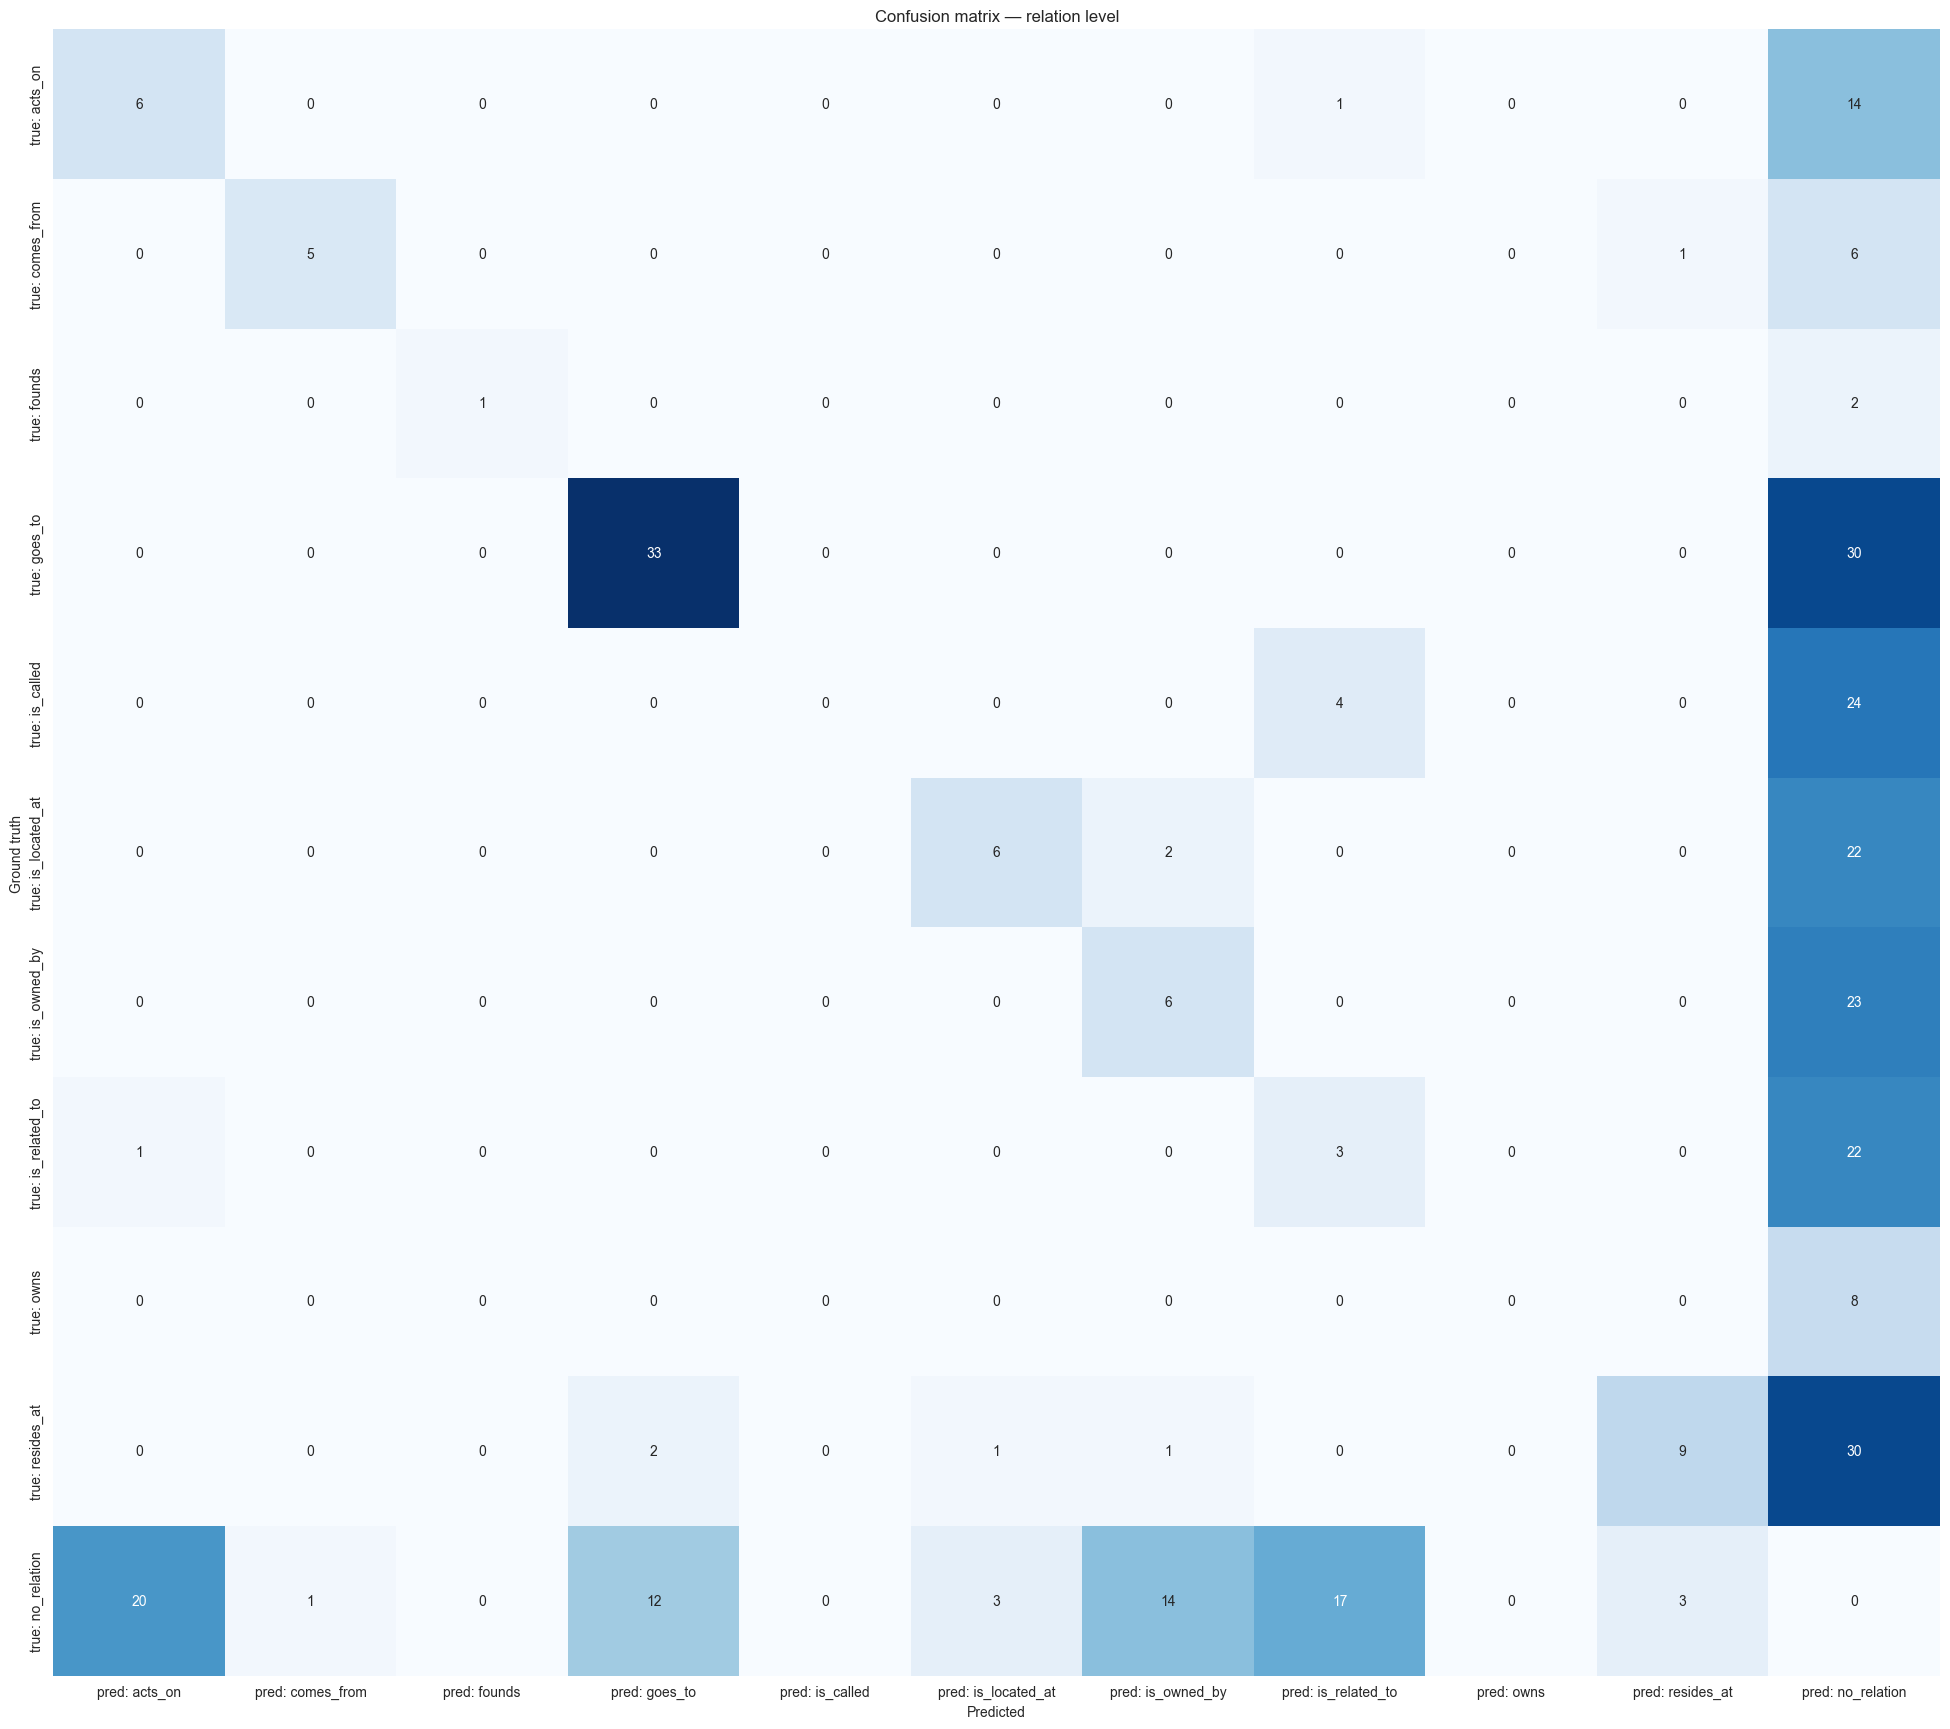

,pred: acts_on,pred: comes_from,pred: founds,pred: goes_to,pred: is_called,pred: is_located_at,pred: is_owned_by,pred: is_related_to,pred: owns,pred: resides_at,pred: no_relation
true: acts_on,6,0,0,0,0,0,0,1,0,0,14
true: comes_from,0,5,0,0,0,0,0,0,0,1,6
true: founds,0,0,1,0,0,0,0,0,0,0,2
true: goes_to,0,0,0,33,0,0,0,0,0,0,30
true: is_called,0,0,0,0,0,0,0,4,0,0,24
true: is_located_at,0,0,0,0,0,6,2,0,0,0,22
true: is_owned_by,0,0,0,0,0,0,6,0,0,0,23
true: is_related_to,1,0,0,0,0,0,0,3,0,0,22
true: owns,0,0,0,0,0,0,0,0,0,0,8
true: resides_at,0,0,0,2,0,1,1,0,0,9,30


In [37]:

cm_labels = relation_labels + ["no_relation"]
cm1 = confusion_matrix(comparison_df.gt_label, comparison_df.pred_label, labels=cm_labels)
cm1_df = pd.DataFrame(cm1, index=[f"true: {l}" for l in cm_labels],
                            columns=[f"pred: {l}" for l in cm_labels])
cm1_df.to_csv(OUTPUT_DIR / "confusion_matrix_relations.csv")

plt.figure(figsize=(1.6 * len(cm_labels) + 2, 1.4 * len(cm_labels) + 2))
sns.heatmap(cm1_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion matrix — relation level")
plt.ylabel("Ground truth")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_relations.png", dpi=150)
plt.show()

cm1_df


## 7. Evaluation 3 — Subtype metrics

A **subtype** is a specific `head_entity_type -> tail_entity_type` pair for a
given relation (e.g. `object->place`, `institution->place`). This shows how
well the pipeline identifies relations broken down by the kinds of entities
involved.

In [39]:

sub_df = comparison_df[comparison_df.subtype != "unknown"].copy()
sub_df["gt_subtype"] = sub_df.apply(
    lambda r: r["subtype"] if r["gt_label"] != "no_relation" else "no_relation", axis=1)
sub_df["pred_subtype"] = sub_df.apply(
    lambda r: r["subtype"] if r["pred_label"] != "no_relation" else "no_relation", axis=1)

subtypes = sorted((set(sub_df.gt_subtype) | set(sub_df.pred_subtype)) - {"no_relation"})

p, r, f, s = precision_recall_fscore_support(
    sub_df.gt_subtype, sub_df.pred_subtype, labels=subtypes, zero_division=0)

subtype_metrics_df = pd.DataFrame({
    "subtype": subtypes,
    "gt_count": s,
    "precision": p.round(3),
    "recall": r.round(3),
    "f1": f.round(3),
}).sort_values("gt_count", ascending=False).reset_index(drop=True)

subtype_metrics_df.to_csv(OUTPUT_DIR / "subtype_metrics.csv", index=False)
subtype_metrics_df


,subtype,gt_count,precision,recall,f1
0,object->person,8,0.600,0.375,0.462
1,object->place,8,0.000,0.000,0.000
2,pronoun->institution,8,0.000,0.000,0.000
3,person->person,8,0.125,0.125,0.125
4,person->place,6,0.500,0.167,0.250
5,person->institution,3,0.500,0.333,0.400
6,pronoun->place,3,0.000,0.000,0.000
7,object->group,3,0.000,0.000,0.000
8,place->institution,2,0.000,0.000,0.000
9,person->object,2,0.000,0.000,0.000


## 8. Evaluation 4 — Subtype confusion matrix

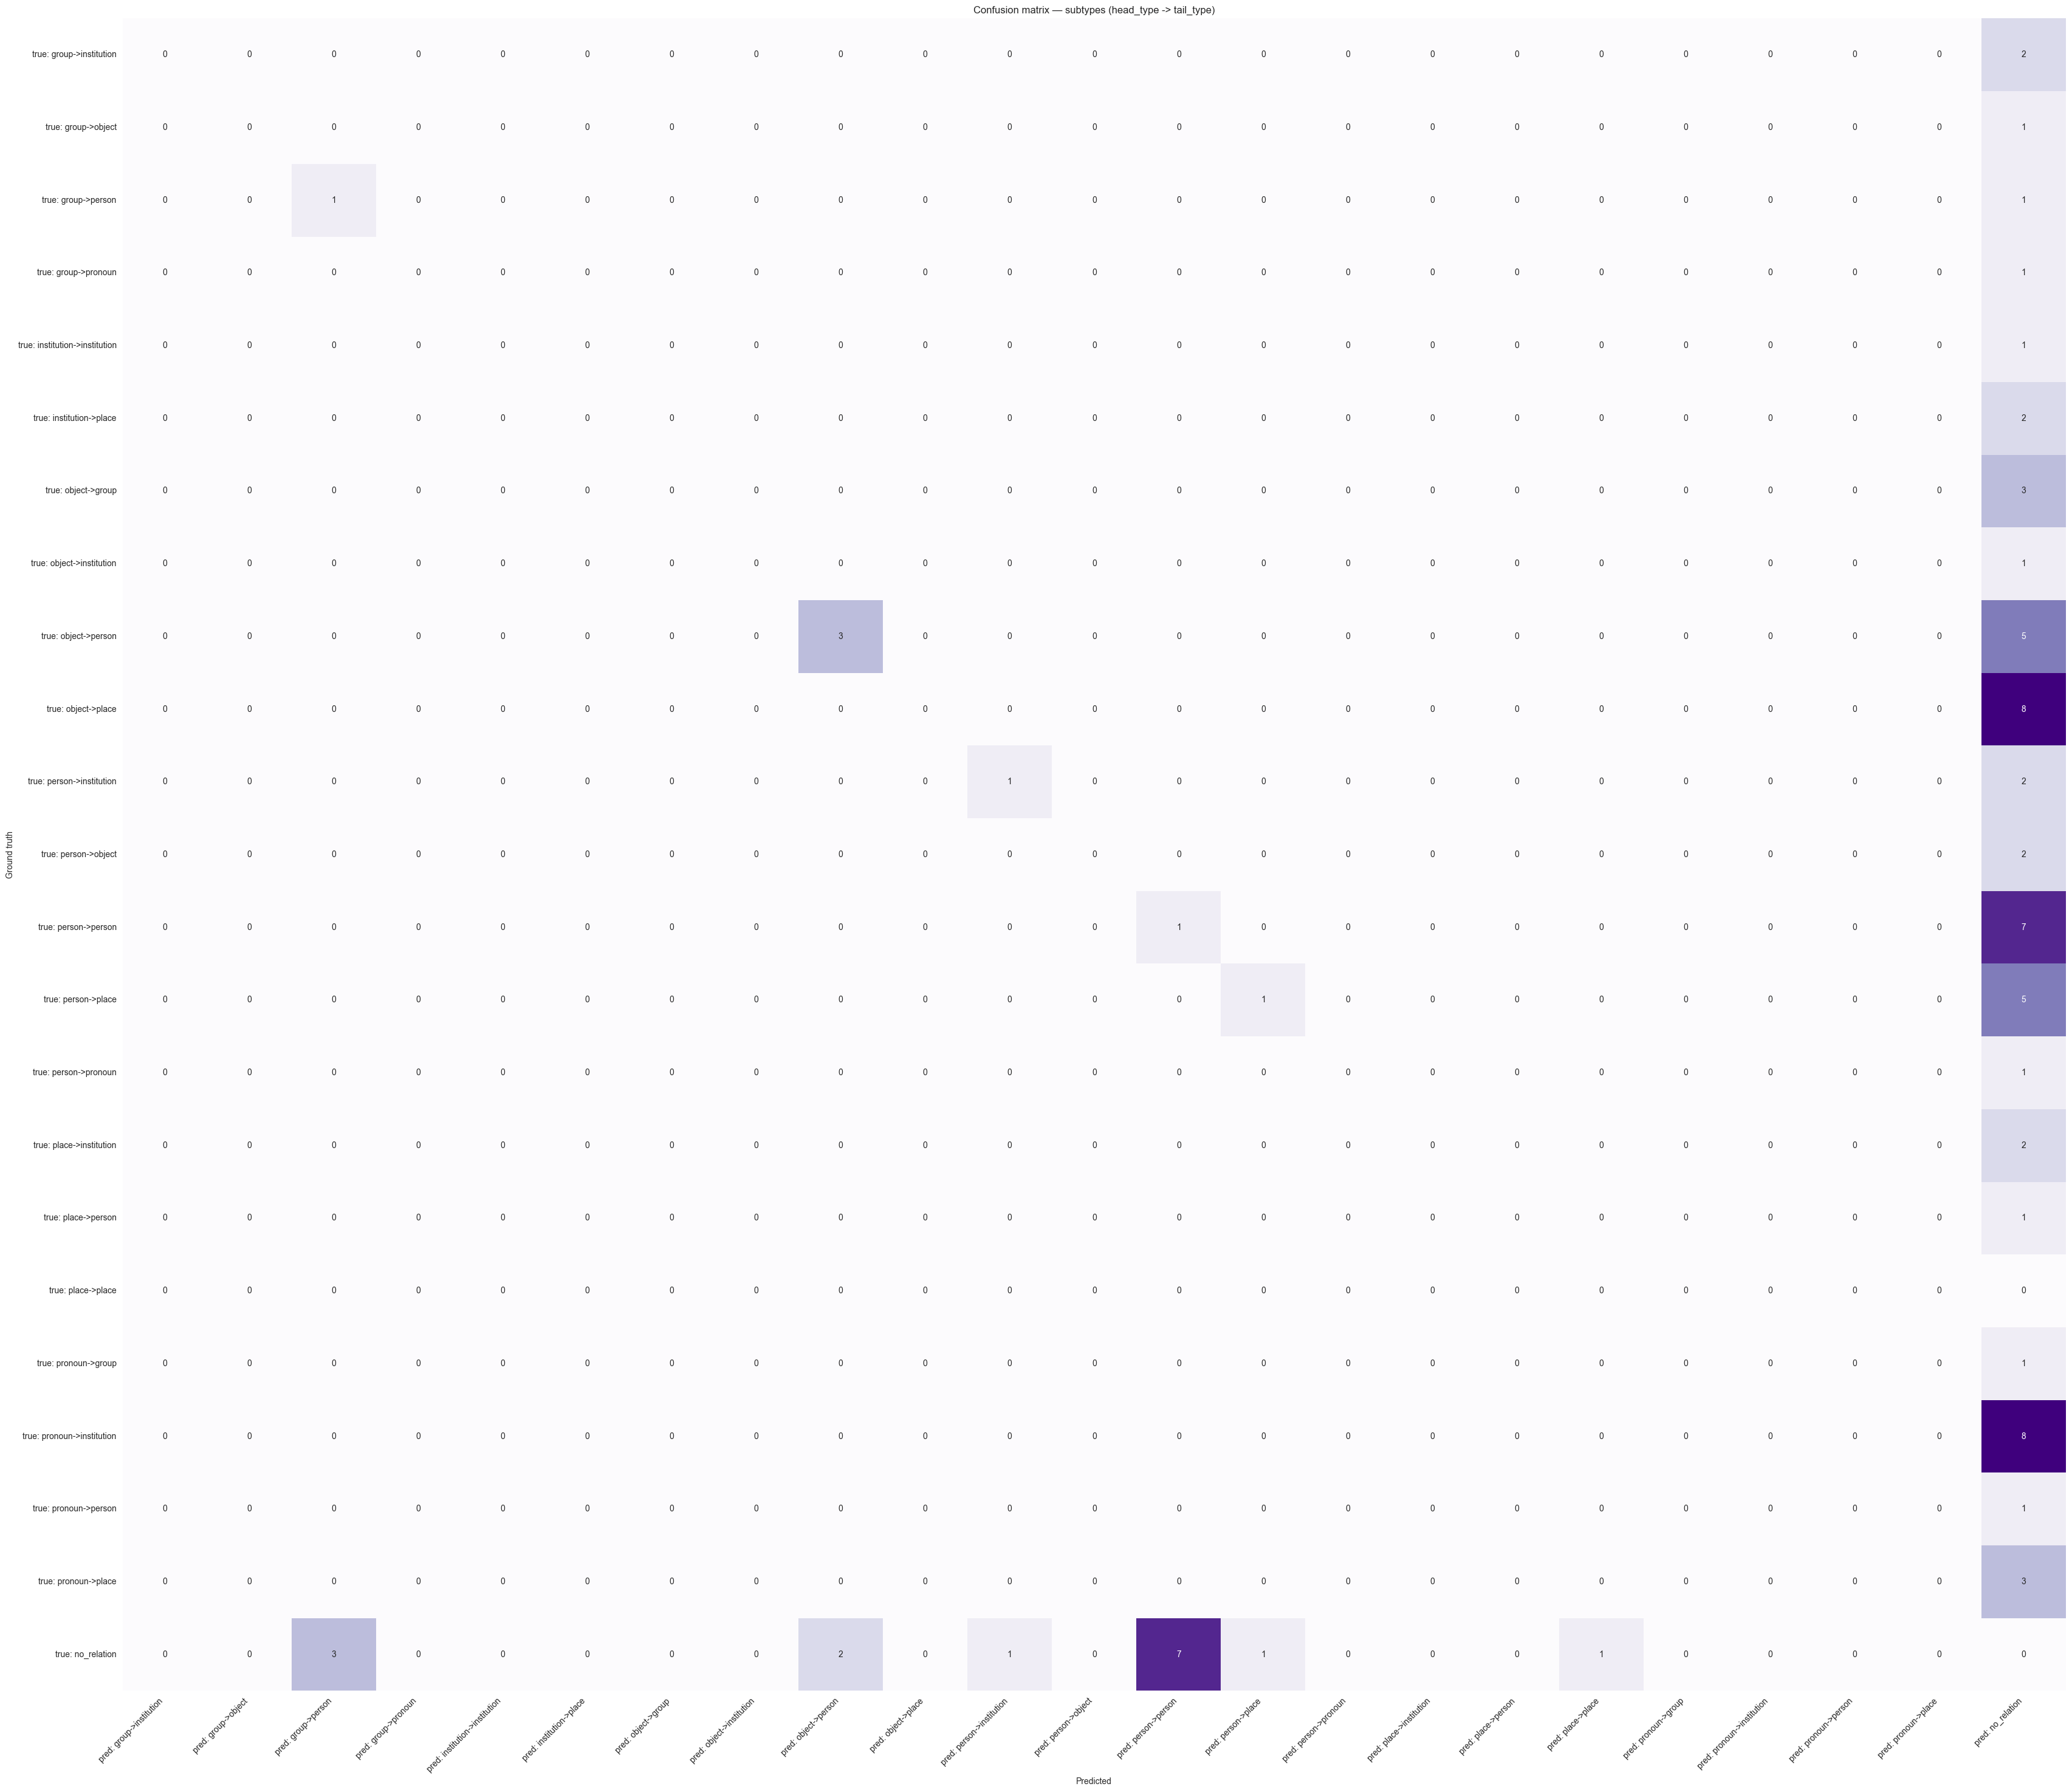

,pred: group->institution,pred: group->object,pred: group->person,pred: group->pronoun,pred: institution->institution,pred: institution->place,pred: object->group,pred: object->institution,pred: object->person,pred: object->place,...,pred: person->place,pred: person->pronoun,pred: place->institution,pred: place->person,pred: place->place,pred: pronoun->group,pred: pronoun->institution,pred: pronoun->person,pred: pronoun->place,pred: no_relation
true: group->institution,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
true: group->object,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
true: group->person,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
true: group->pronoun,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
true: institution->institution,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
true: institution->place,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
true: object->group,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
true: object->institution,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
true: object->person,0,0,0,0,0,0,0,0,3,0,...,0,0,0,0,0,0,0,0,0,5
true: object->place,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8


In [40]:

cm2_labels = subtypes + ["no_relation"]
cm2 = confusion_matrix(sub_df.gt_subtype, sub_df.pred_subtype, labels=cm2_labels)
cm2_df = pd.DataFrame(cm2, index=[f"true: {l}" for l in cm2_labels],
                            columns=[f"pred: {l}" for l in cm2_labels])
cm2_df.to_csv(OUTPUT_DIR / "confusion_matrix_subtypes.csv")

plt.figure(figsize=(1.4 * len(cm2_labels) + 2, 1.2 * len(cm2_labels) + 2))
sns.heatmap(cm2_df, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("Confusion matrix — subtypes (head_type -> tail_type)")
plt.ylabel("Ground truth")
plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_subtypes.png", dpi=150)
plt.show()

cm2_df


## 9. Summary

In [41]:

print(f"All evaluation artifacts saved to: {OUTPUT_DIR}\n")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(" -", f.name)


All evaluation artifacts saved to: C:\Users\Heike\PycharmProjects\Hagiographics-relation-extraction\evaluation\hagio_preannotation_gemini_eval

 - comparison_table.csv
 - confusion_matrix_relations.csv
 - confusion_matrix_relations.png
 - confusion_matrix_subtypes.csv
 - confusion_matrix_subtypes.png
 - overall_metrics.csv
 - subtype_metrics.csv
